# Stock Investment Notebook - CS4650 Project #4

## Week#1 -  "Higher Risk, Higher Reward!"

Refrence: https://www.investopedia.com/terms/r/riskreturntradeoff.asp

Using this method, i intent to use 25% of the initial 250,000 for investing into said stocks. 25% will be distributed between 10 stocks and percent will be allocated depending on thier high/low risk ratios with the higer risk ratios recieving a greater fund allocation. The 10 stock tested for this method where chossen based off of market cap. 5 of the random stocks chosen had a market cap > 200B and the other 5 random stocks chosen had a market cap < 100B.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# fix_yahoo_finance is used to fetch data 
import yfinance as yf
from pandas_datareader import data as pdr
yf.pdr_override()

In [2]:
# inputs
symbols = ['AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL']
start = '2015-01-01'
end = '2021-11-11'

In [3]:
df = pd.DataFrame()
data = []
for symbol in symbols:
    df = pd.merge(df, pd.DataFrame(yf.download(symbol, fields='price', 
                           start=start, end=end)['Adj Close']), 
                           right_index=True, left_index=True, how='outer')
       
    # Appends tickers which have data
    data.append(symbol)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
df.columns = data
df = df.dropna(axis='columns')
df.head()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
Date,,,,,,,,,,
2015-01-02,24.745998,43.862000,87.376266,30.078136,1142.060059,12.815,0.384714,86.516472,21.286667,47.980000
2015-01-05,24.048859,42.018002,86.099396,29.738970,1097.579956,12.580,0.384714,85.181778,21.296667,46.290001
2015-01-06,24.051130,42.256001,85.642700,29.184725,1079.959961,12.700,0.371215,85.062119,21.170000,46.570000
2015-01-07,24.388371,42.189999,86.518799,29.796873,1069.569946,12.725,0.391463,86.672974,21.666668,48.720001
2015-01-08,25.325436,42.124001,87.413536,30.351112,1082.849976,13.065,0.398213,88.145729,22.191668,48.740002


In [5]:
df.tail()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
Date,,,,,,,,,,
2021-11-04,150.740005,1229.910034,170.279999,50.310001,2437.010010,28.670000,0.36,270.059998,117.370003,293.839996
2021-11-05,151.279999,1222.089966,175.630005,50.919998,2618.969971,28.629999,0.36,276.160004,118.650002,297.880005
2021-11-08,150.440002,1162.939941,176.869995,51.549999,2639.860107,28.520000,0.36,275.549988,119.540001,293.429993
2021-11-09,150.809998,1023.500000,175.110001,51.200001,2648.199951,28.600000,0.35,275.170013,120.040001,299.250000
2021-11-10,147.919998,1067.949951,174.449997,50.759998,2569.780029,29.110001,0.35,271.059998,118.769997,292.630005


In [6]:
df.describe()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.00000,1728.000000,1728.000000,1728.000000,1728.000000
mean,57.749412,174.154634,118.389457,41.410110,1737.417918,22.57568,0.349445,159.957323,53.777951,146.110735
std,38.321250,242.040223,28.370748,11.396694,363.240636,2.89090,0.042400,54.630044,25.736708,81.254682
min,21.036303,28.733999,83.824921,21.890186,973.799988,12.58000,0.242977,81.786125,20.643333,40.700001
25%,28.618144,46.396499,98.900032,30.548968,1410.795013,21.16750,0.322179,108.728666,32.424168,76.787500
50%,42.106890,61.184999,107.638081,43.367489,1791.010010,22.98250,0.350000,158.952362,46.731667,140.415001
75%,71.381454,114.480001,131.980312,50.312150,1991.657501,24.28875,0.373325,200.365971,74.529999,198.007500
max,156.461655,1229.910034,201.910004,66.938637,2648.199951,29.76000,0.492704,279.431152,122.750000,352.640015


## Calculate Stock Returns

In [7]:
from IPython.display import Latex, HTML

Latex(r"""\begin{eqnarray}r_t = \frac{AdjClose_t - AdjClose_{t-1}}{AdjClose_{t-1}} = \frac{AdjClose_t}{AdjClose_{t-1}} - 1
\end{eqnarray}""")

<IPython.core.display.Latex object>

([<matplotlib.axis.YTick at 0x17a86148160>,
 [Text(0, 0, 'AAPL'),
  Text(0, 1, 'TSLA'),
  Text(0, 2, 'DIS'),
  Text(0, 3, 'INTC'),
  Text(0, 4, 'BKNG'),
  Text(0, 5, 'NTTYY'),
  Text(0, 6, 'BACHF'),
  Text(0, 7, 'SYK'),
  Text(0, 8, 'EW'),
  Text(0, 9, 'BURL')])

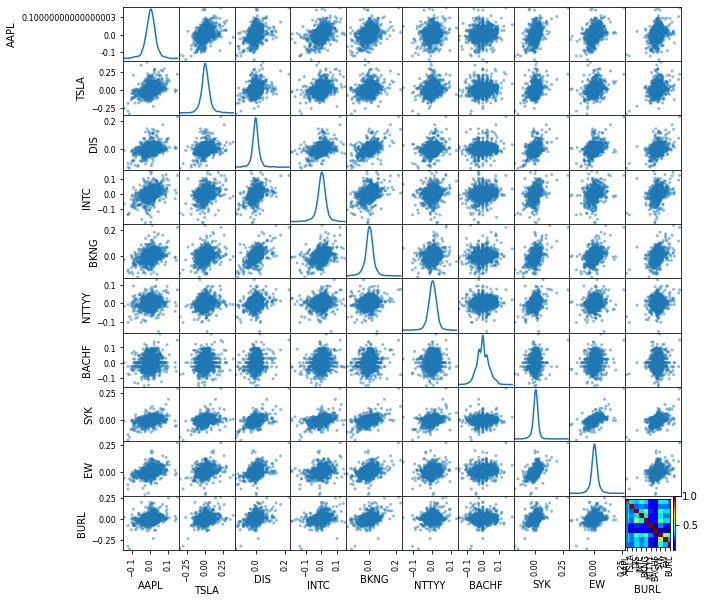

In [8]:
from pandas.plotting import scatter_matrix

rets = df.pct_change(periods=3)
scatter_matrix(rets, diagonal='kde', figsize=(10, 10))
corr = rets.corr()
plt.imshow(corr, cmap='jet', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)

Text(0, 0.5, 'Standard Deviations')

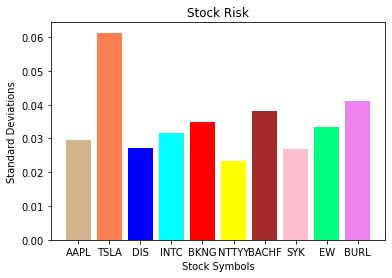

In [9]:
plt.bar(rets.columns, rets.std(), color=['tan', 'coral', 'blue', 'cyan', 'red', 'yellow', 'brown', 'pink', 'springgreen', 'violet'])
plt.title("Stock Risk")
plt.xlabel("Stock Symbols")
plt.ylabel("Standard Deviations")

Text(0, 0.5, 'Returns')

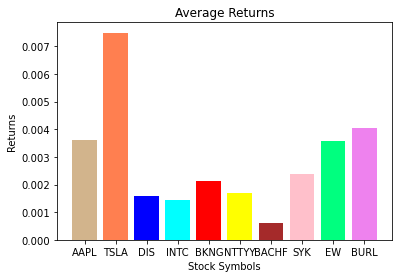

In [10]:
plt.bar(rets.columns, rets.mean(), color=['tan', 'coral', 'blue', 'cyan', 'red', 'yellow', 'brown', 'pink', 'springgreen', 'violet'])
plt.title("Average Returns")
plt.xlabel("Stock Symbols")
plt.ylabel("Returns")

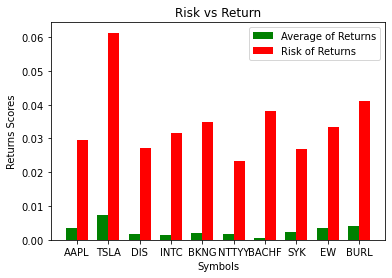

In [11]:
ind = np.arange(10)
width = 0.35       
plt.bar(ind, rets.mean(), width, color = 'g', label='Average of Returns')
plt.bar(ind + width, rets.std(), width, color = 'r', label='Risk of Returns')
plt.ylabel('Returns Scores')
plt.xlabel('Symbols')
plt.title('Risk vs Return')

plt.xticks(ind + width / 2, ('AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL'))
plt.legend(loc='best')
plt.show()

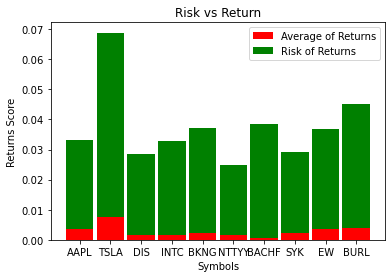

In [12]:
symbols = ['AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL']
ind = [x for x, _ in enumerate(symbols)]

plt.bar(ind, rets.mean(), width=0.9, label='Average of Returns', color='r')
plt.bar(ind, rets.std(), width=0.9, label='Risk of Returns', color='g', bottom=rets.mean())

plt.xticks(ind, symbols)
plt.ylabel("Returns Score")
plt.xlabel("Symbols")
plt.legend(loc="upper right")
plt.title('Risk vs Return')
plt.show()

## Risk vs Expected Return

In [13]:
d = {'Risk':rets.std(), 'Expected Returns':rets.mean()}
print('Table: Risk vs Expected Returns')
tables = pd.DataFrame(data=d)
tables   

Table: Risk vs Expected Returns


,Risk,Expected Returns
AAPL,0.029686,0.003610
TSLA,0.061326,0.007492
DIS,0.027067,0.001596
INTC,0.031483,0.001451
BKNG,0.034964,0.002110
NTTYY,0.023257,0.001693
BACHF,0.037995,0.000593
SYK,0.026895,0.002386
EW,0.033400,0.003563
BURL,0.041032,0.004051


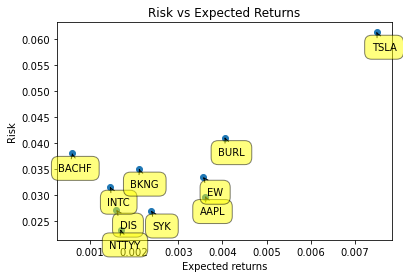

In [14]:
plt.scatter(rets.mean(), rets.std())
plt.xlabel('Expected returns')
plt.ylabel('Risk')
for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.title('Risk vs Expected Returns')
    plt.annotate(
        label, 
        xy = (x, y), xytext = (20, -20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.7', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))

## Week #1 Trade Exeucutions:

Week #1: Starting funds as of 11/12: $250,000

Given these results, money in each stock was allocated as such:

![Trade History](week1images\TradeHistory.PNG)

Total Funds Allocated: $61,348.31

Performance History:

![Performance History](week1images\performanceHistory.PNG)

In [15]:
#Week 1 Funds
week1start = 250000.00
week2end = 250853.01


#Week 1 starting funds
print("Week #1 starting funds as of 11/19: ${}".format(week1start))

#Week 1 ending funds
print("Week #1 ending funds as of 11/19: ${}".format(week2end))

# Percent gain/loss
percentDiffrence = ((week1start - week2end)/((week1start + week2end)/2))*-100
print("Week #1 percent gain/loss was: +{}%".format(percentDiffrence))

#Profit
gain_loss = week2end - week1start
print("Week #1 profit as of 11/19: ${}".format(gain_loss))

Week #1 ending funds as of 11/19: $250000.0
Week #1 ending funds as of 11/19: $250853.01
Week #1 percent gain/loss was: +0.34062289053629097%
Week #1 profit as of 11/19: $853.0100000000093


![Performance](week1images\performance.PNG)

# Week#2 -  Long short-term memory (LSTM)

Refrence: https://www.analyticsvidhya.com/blog/2021/03/introduction-to-long-short-term-memory-lstm/

Using this method, i intent to use 25% of the initial 250,000 for investing into said stocks. 25% will be distributed between 10 stocks and percent will be allocated evenly between the 5 chosen stock. This model will use the "recurent neural network called Long Short Term Memory (LSTM)" to build the forecast. It will use the last 60 days for this.

In [3]:
#import libraries
import yfinance as yf
import yahoofinancials
import math 
import pandas as pd 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [5]:
AAPL = yf.download('SPY', 
                      start='2015-01-01', 
                      end='2022-01-01', 
                      progress=False)
AAPL

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,206.380005,206.880005,204.179993,205.429993,180.976273,121465900
2015-01-05,204.169998,204.369995,201.350006,201.720001,177.707870,169632600
2015-01-06,202.089996,202.720001,198.860001,199.820007,176.034042,209151400
2015-01-07,201.419998,202.720001,200.880005,202.309998,178.227646,125346700
2015-01-08,204.009995,206.160004,203.990005,205.899994,181.390274,147217800
...,...,...,...,...,...,...
2021-11-18,469.239990,470.010010,466.339996,469.730011,469.730011,50625600
2021-11-19,469.609985,470.940002,468.500000,468.890015,468.890015,57288900
2021-11-22,470.890015,473.540009,467.350006,467.570007,467.570007,72762000


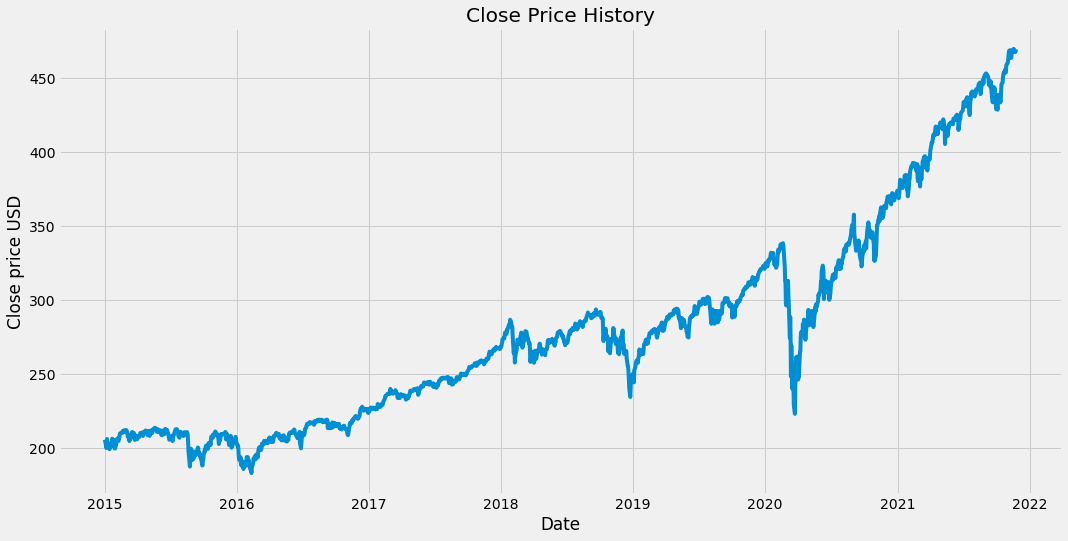

In [6]:
plt.figure(figsize = (16,8))
plt.title('Close Price History')
plt.plot(AAPL['Close'])
plt.xlabel('Date')
plt.ylabel('Close price USD')
plt.show()

In [11]:
# Create a new dataframe with only a column "Close"
data = AAPL.filter(['Close'])

# convert to numpaev array
dataset = data.values

# pulls out the number of rows in the date for training the model (LSTM)
training_data_len = math.ceil(len(dataset) * .8)
training_data_len

1391

In [13]:
# Scale the data (scalable)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset) 
scaled_data

array([[0.07867672],
       [0.06574407],
       [0.05912088],
       ...,
       [0.99247044],
       [0.99463169],
       [0.99898906]])

In [14]:
# Create a dataset for training
train_data = scaled_data[0:training_data_len]

# split into x underscore train and underscore train 
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i])
    y_train.append(train_data[i])

In [15]:
# Convert x_train and y_train to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

In [16]:
# Reshape data
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],x_train.shape[2]))

In [17]:
# Building the neuron
model = Sequential()
model.add(LSTM(50,return_sequences = True, input_shape = (x_train.shape[1],x_train.shape[2])))
model.add(LSTM(50,return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

In [19]:
# Compile the model
model.compile(optimizer='adam',loss = 'mean_squared_error')

In [20]:
# Train the model
model.fit(x_train,y_train,batch_size = 1, epochs = 10)

Epoch 1/10
1331/1331 [==============================] - 17s 12ms/step - loss: 0.0013 0s - loss: 0.00
Epoch 2/10
1331/1331 [==============================] - 15s 12ms/step - loss: 4.1373e-04
Epoch 3/10
1331/1331 [==============================] - 15s 12ms/step - loss: 3.6534e-04
Epoch 4/10
1331/1331 [==============================] - 15s 11ms/step - loss: 2.5891e-04
Epoch 5/10
1331/1331 [==============================] - 15s 11ms/step - loss: 2.4978e-04
Epoch 6/10
1331/1331 [==============================] - 15s 11ms/step - loss: 2.3289e-04
Epoch 7/10
1331/1331 [==============================] - 15s 12ms/step - loss: 2.2988e-04
Epoch 8/10
1331/1331 [==============================] - 15s 11ms/step - loss: 2.4512e-04
Epoch 9/10
1331/1331 [==============================] - 16s 12ms/step - loss: 2.1184e-04
Epoch 10/10
1331/1331 [==============================] - 16s 12ms/step - loss: 2.0104e-04


In [21]:
# Create a test dataset
test_data = scaled_data[training_data_len - 60:]

# by analogy, create x_test and y_test
x_test = []
y_test = dataset[training_data_len:]
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i])

In [22]:
# again transform into a numpy array
x_test = np.array(x_test)

In [23]:
# reshape again
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],x_test.shape[2]))

In [24]:
# Getting a model predicting values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

In [25]:
# Get mean squared error (RMSE) - least squares method
rmse =np.sqrt(np.mean(predictions-y_test)**2)
rmse

3.9118094760334112

# Visualize

C:\Users\Public\Documents\Wondershare\CreatorTemp/ipykernel_6132/613305967.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


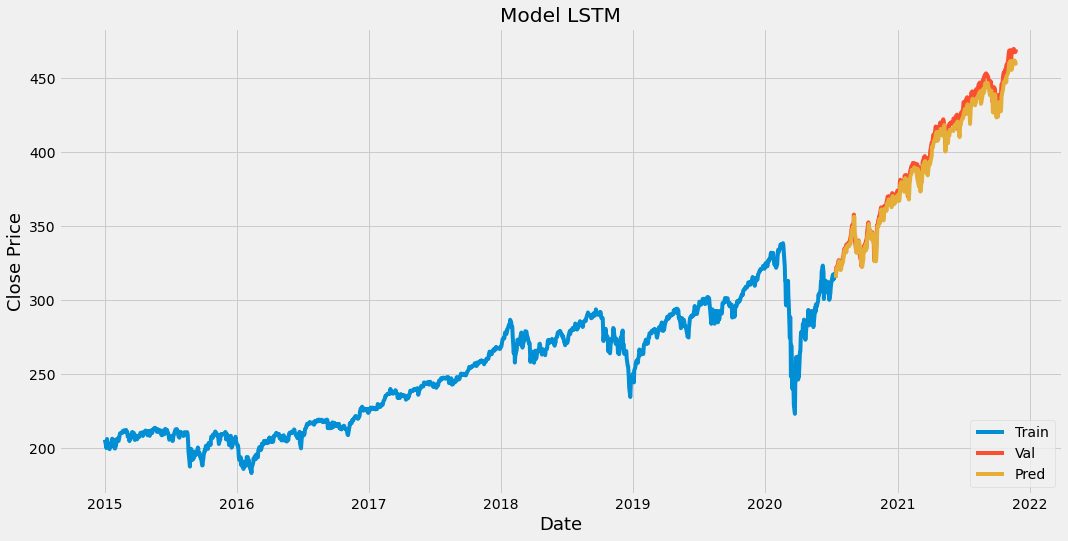

In [26]:
# build a schedule
train = data[:training_data_len]
valid = data[training_data_len: ]
valid['Predictions'] = predictions

# visualize
plt.figure(figsize=(16,8))
plt.title('Model LSTM')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price',fontsize = 18)
plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Train','Val','Pred'], loc = 'lower right')
plt.show()

# Week #2 Trade Exeucutions:

Week #2: Starting funds as of 11/19: $250853.01

Given these results, money in each stock was allocated as such:

![Trade History](week2images\stocks_bought.PNG)

Total Funds Allocated: $62,998.71

In [1]:
#Week 2 Funds
week2start = 250853.01
week2end = 252071.11


#Week 2 starting funds
print("Week #2 starting funds as of 11/19: ${}".format(week2start))

#Week 2 ending funds
print("Week #2 ending funds as of 11/19: ${}".format(week2end))

# Percent gain/loss
percentDiffrence = ((week2start - week2end)/((week2start + week2end)/2))*-100
print("Week #2 percent gain/loss was: +{}%".format(percentDiffrence))

#Profit
gain_loss = week2end - week2start
print("Week #2 profit as of 11/26: ${}".format(gain_loss))

Week #2 starting funds as of 11/19: $250853.01
Week #2 ending funds as of 11/19: $252071.11
Week #2 percent gain/loss was: +0.4844070711899746%
Week #2 profit as of 11/26: $1218.0999999999767


Performance History:

![Trade History](week2images\performance.PNG)

# Week #3 -  Stacked Long short-term memory (SLSTM)

Refrence: https://machinelearningmastery.com/stacked-long-short-term-memory-networks/

Using this method, i intent to use 25% of the initial 250,000 for investing into said stocks. 25% will be distributed between 5 stocks and percent will be allocated evenly between the 5 chosen stock. This model will use the stacked recurent neural network called Long Short Term Memory or (SLSTM) to build the forecast.

In [152]:
### Keras and Tensorflow >2.0

### Data Collection
import pandas_datareader as pdr
key="63e6749fef643ae4ce2f0af4bba9f85ae11f29c3"

In [153]:
df = pdr.get_data_tiingo('PYPL', api_key=key)

In [154]:
df.to_csv('PYPL.csv')

In [155]:
import pandas as pd

In [156]:
df=pd.read_csv('PYPL.csv')

In [157]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,PYPL,2016-12-05 00:00:00+00:00,38.99,39.34,38.650,38.85,5053862,38.99,39.34,38.650,38.85,5053862,0.0,1.0
1,PYPL,2016-12-06 00:00:00+00:00,38.98,39.26,38.710,39.23,5954455,38.98,39.26,38.710,39.23,5954455,0.0,1.0
2,PYPL,2016-12-07 00:00:00+00:00,39.45,39.46,38.800,39.08,7012032,39.45,39.46,38.800,39.08,7012032,0.0,1.0
3,PYPL,2016-12-08 00:00:00+00:00,39.61,40.00,39.450,39.68,6102590,39.61,40.00,39.450,39.68,6102590,0.0,1.0
4,PYPL,2016-12-09 00:00:00+00:00,39.65,39.79,39.375,39.70,3923741,39.65,39.79,39.375,39.70,3923741,0.0,1.0


In [158]:
df.tail()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
1252,PYPL,2021-11-24 00:00:00+00:00,188.71,189.640,184.74,187.00,13359144,188.71,189.640,184.74,187.00,13359144,0.0,1.0
1253,PYPL,2021-11-26 00:00:00+00:00,187.79,193.000,186.83,188.38,11080417,187.79,193.000,186.83,188.38,11080417,0.0,1.0
1254,PYPL,2021-11-29 00:00:00+00:00,187.24,189.900,182.43,188.92,16308218,187.24,189.900,182.43,188.92,16308218,0.0,1.0
1255,PYPL,2021-11-30 00:00:00+00:00,184.89,188.825,180.50,186.47,21144293,184.89,188.825,180.50,186.47,21144293,0.0,1.0
1256,PYPL,2021-12-01 00:00:00+00:00,179.32,190.350,179.15,187.77,19542916,179.32,190.350,179.15,187.77,19542916,0.0,1.0


In [159]:
df1=df.reset_index()['close']

In [160]:
df1

0        38.99
1        38.98
2        39.45
3        39.61
4        39.65
         ...  
1252    188.71
1253    187.79
1254    187.24
1255    184.89
1256    179.32
Name: close, Length: 1257, dtype: float64

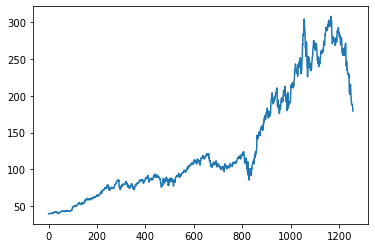

In [161]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [162]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler 

In [163]:
import numpy as np

In [164]:
df1

0        38.99
1        38.98
2        39.45
3        39.61
4        39.65
         ...  
1252    188.71
1253    187.79
1254    187.24
1255    184.89
1256    179.32
Name: close, Length: 1257, dtype: float64

In [165]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [166]:
print(df1)

[[3.70988685e-05]
 [0.00000000e+00]
 [1.74364682e-03]
 ...
 [5.50027824e-01]
 [5.41309590e-01]
 [5.20645520e-01]]


In [167]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [168]:
training_size,test_size

(817, 440)

In [169]:
train_data

array([[3.70988685e-05],
       [0.00000000e+00],
       [1.74364682e-03],
       [2.33722871e-03],
       [2.48562419e-03],
       [1.66944908e-03],
       [1.66944908e-03],
       [2.11463550e-03],
       [2.07753664e-03],
       [1.26136153e-03],
       [1.70654795e-03],
       [2.81951400e-03],
       [4.11797440e-03],
       [2.59692079e-03],
       [2.22593211e-03],
       [2.74531627e-03],
       [2.18883324e-03],
       [3.63568911e-03],
       [1.81784456e-03],
       [4.71155630e-03],
       [7.49397143e-03],
       [7.71656464e-03],
       [9.16342052e-03],
       [8.97792617e-03],
       [7.79076238e-03],
       [8.53273975e-03],
       [9.57150807e-03],
       [9.71990354e-03],
       [8.49564088e-03],
       [8.79243183e-03],
       [8.49564088e-03],
       [1.00537934e-02],
       [9.79410128e-03],
       [1.10554628e-02],
       [1.01279911e-02],
       [9.34891486e-03],
       [4.78575403e-03],
       [3.26470043e-03],
       [2.96790948e-03],
       [1.22426266e-03],


In [170]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [171]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [172]:
print(X_train.shape), print(y_train.shape)

(716, 100)
(716,)


(None, None)

In [173]:
print(X_test.shape), print(ytest.shape)

(339, 100)
(339,)


(None, None)

In [174]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [175]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [176]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

In [177]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 100, 50)           10400     
                                                                 
 lstm_7 (LSTM)               (None, 100, 50)           20200     
                                                                 
 lstm_8 (LSTM)               (None, 50)                20200     
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 50,851
Trainable params: 50,851
Non-trainable params: 0
_________________________________________________________________


In [178]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 100, 50)           10400     
                                                                 
 lstm_7 (LSTM)               (None, 100, 50)           20200     
                                                                 
 lstm_8 (LSTM)               (None, 50)                20200     
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 50,851
Trainable params: 50,851
Non-trainable params: 0
_________________________________________________________________


In [179]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
12/12 [==============================] - 5s 133ms/step - loss: 0.0130 - val_loss: 0.1210
Epoch 2/100
12/12 [==============================] - 1s 71ms/step - loss: 0.0023 - val_loss: 0.0419
Epoch 3/100
12/12 [==============================] - 1s 71ms/step - loss: 0.0012 - val_loss: 0.0292
Epoch 4/100
12/12 [==============================] - 1s 70ms/step - loss: 3.5817e-04 - val_loss: 0.0045
Epoch 5/100
12/12 [==============================] - 1s 70ms/step - loss: 2.4106e-04 - val_loss: 0.0045
Epoch 6/100
12/12 [==============================] - 1s 69ms/step - loss: 2.0106e-04 - val_loss: 0.0047
Epoch 7/100
12/12 [==============================] - 1s 69ms/step - loss: 1.9834e-04 - val_loss: 0.0044
Epoch 8/100
12/12 [==============================] - 1s 69ms/step - loss: 2.0750e-04 - val_loss: 0.0041
Epoch 9/100
12/12 [==============================] - 1s 70ms/step - loss: 1.9376e-04 - val_loss: 0.0041
Epoch 10/100
12/12 [==============================] - 1s 69ms/step - loss: 

In [180]:
import tensorflow as tf

In [181]:
tf.__version__

'2.7.0'

In [182]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

In [183]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [184]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

88.76447197570941

In [185]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

227.83179431580987

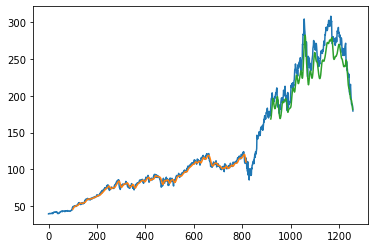

In [186]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [187]:
len(test_data)

440

In [188]:
test_data = np.append(test_data, 1.03393863e-01)

In [189]:
x_input=test_data[341:].reshape(1,-1)
x_input.shape

(1, 100)

In [190]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [191]:
temp_input

[0.9711370803190505,
 0.9554071600816177,
 0.9484325728065296,
 0.9492487479131889,
 0.9611945835652015,
 0.9749211649044706,
 0.9820441476534968,
 1.0,
 0.9935818957521799,
 0.9701354108699688,
 0.9757002411426455,
 0.9059172695232799,
 0.877573734001113,
 0.8607308477091452,
 0.8700426636987574,
 0.8774624373956598,
 0.8966425524021521,
 0.8924503802634022,
 0.8872936375440551,
 0.8732702652569099,
 0.8808384344277503,
 0.874086440363569,
 0.8752736041550736,
 0.8877759228343537,
 0.8611389352624749,
 0.8527545909849751,
 0.8592097941012801,
 0.8680393248005936,
 0.8829530699313674,
 0.8923390836579487,
 0.8855870895937675,
 0.8704878501205716,
 0.8879614171767763,
 0.9255796698200708,
 0.9262845483212766,
 0.9191986644407347,
 0.9146726024856243,
 0.9280281951400485,
 0.9433500278241517,
 0.9135596364310891,
 0.9196809497310335,
 0.9101836393989985,
 0.8959747727694308,
 0.9024670747542202,
 0.903171953255426,
 0.9051752921535897,
 0.8805787423483585,
 0.856724169912818,
 0.85516601

In [192]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
    

print(lst_output)

[0.48020804]
101
1 day input [0.95540716 0.94843257 0.94924875 0.96119458 0.97492116 0.98204415
 1.         0.9935819  0.97013541 0.97570024 0.90591727 0.87757373
 0.86073085 0.87004266 0.87746244 0.89664255 0.89245038 0.88729364
 0.87327027 0.88083843 0.87408644 0.8752736  0.88777592 0.86113894
 0.85275459 0.85920979 0.86803932 0.88295307 0.89233908 0.88558709
 0.87048785 0.88796142 0.92557967 0.92628455 0.91919866 0.9146726
 0.9280282  0.94335003 0.91355964 0.91968095 0.91018364 0.89597477
 0.90246707 0.90317195 0.90517529 0.88057874 0.85672417 0.85516602
 0.86573919 0.89081803 0.88714524 0.86963458 0.82808384 0.8162493
 0.82073827 0.83721017 0.80144686 0.82051567 0.83502133 0.83309219
 0.82018178 0.80159525 0.80456316 0.8064552  0.84388796 0.85093675
 0.85828232 0.86336487 0.81387498 0.75767019 0.74724541 0.77128548
 0.75689111 0.72698943 0.73400111 0.71827119 0.71341124 0.70665925
 0.71007234 0.70205899 0.69300686 0.70651085 0.61747357 0.61457986
 0.60489705 0.62815804 0.64388796 0

14 day output [[0.36339107]]
15 day input [0.87746244 0.89664255 0.89245038 0.88729364 0.87327027 0.88083843
 0.87408644 0.8752736  0.88777592 0.86113894 0.85275459 0.85920979
 0.86803932 0.88295307 0.89233908 0.88558709 0.87048785 0.88796142
 0.92557967 0.92628455 0.91919866 0.9146726  0.9280282  0.94335003
 0.91355964 0.91968095 0.91018364 0.89597477 0.90246707 0.90317195
 0.90517529 0.88057874 0.85672417 0.85516602 0.86573919 0.89081803
 0.88714524 0.86963458 0.82808384 0.8162493  0.82073827 0.83721017
 0.80144686 0.82051567 0.83502133 0.83309219 0.82018178 0.80159525
 0.80456316 0.8064552  0.84388796 0.85093675 0.85828232 0.86336487
 0.81387498 0.75767019 0.74724541 0.77128548 0.75689111 0.72698943
 0.73400111 0.71827119 0.71341124 0.70665925 0.71007234 0.70205899
 0.69300686 0.70651085 0.61747357 0.61457986 0.60489705 0.62815804
 0.64388796 0.65549991 0.62062697 0.59922092 0.5736598  0.55833797
 0.55303283 0.55548136 0.55206826 0.55002782 0.54130959 0.52064552
 0.10339386 0.480208

28 day output [[0.36772048]]
29 day input [0.89233908 0.88558709 0.87048785 0.88796142 0.92557967 0.92628455
 0.91919866 0.9146726  0.9280282  0.94335003 0.91355964 0.91968095
 0.91018364 0.89597477 0.90246707 0.90317195 0.90517529 0.88057874
 0.85672417 0.85516602 0.86573919 0.89081803 0.88714524 0.86963458
 0.82808384 0.8162493  0.82073827 0.83721017 0.80144686 0.82051567
 0.83502133 0.83309219 0.82018178 0.80159525 0.80456316 0.8064552
 0.84388796 0.85093675 0.85828232 0.86336487 0.81387498 0.75767019
 0.74724541 0.77128548 0.75689111 0.72698943 0.73400111 0.71827119
 0.71341124 0.70665925 0.71007234 0.70205899 0.69300686 0.70651085
 0.61747357 0.61457986 0.60489705 0.62815804 0.64388796 0.65549991
 0.62062697 0.59922092 0.5736598  0.55833797 0.55303283 0.55548136
 0.55206826 0.55002782 0.54130959 0.52064552 0.10339386 0.48020804
 0.44468677 0.41502604 0.39303952 0.37801218 0.36837327 0.36254609
 0.35928124 0.35770985 0.35727477 0.3576313  0.35856143 0.3599118
 0.36155894 0.36339107

In [193]:
day_new=np.arange(1,100)
day_pred=np.arange(101,131)

In [194]:
import matplotlib.pyplot as plt

In [195]:
len(df1)

1257

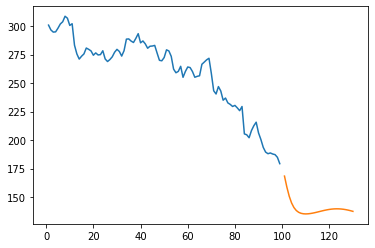

In [196]:
plt.plot(day_new,scaler.inverse_transform(df1[1158:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

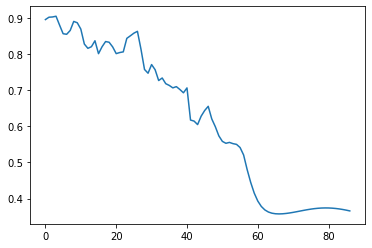

In [197]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [198]:
df3=scaler.inverse_transform(df3).tolist()

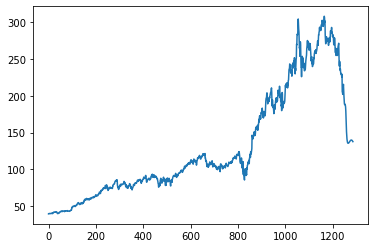

In [199]:
plt.plot(df3)

# Week #3 Trade Exeucutions:

Week #3: Starting funds as of 11/26: $252071.11

Given these results, money in each stock was allocated as such:

![Trade History](week3images\positions.PNG)

Total Funds Allocated: $63,076.98

In [2]:
#Week 3 Funds
week3start = 252071.11
week3end = 245296.57


#Week 3 starting funds
print("Week #3 starting funds as of 11/26: ${}".format(week3start))

#Week 3 ending funds
print("Week #3 ending funds as of 11/26: ${}".format(week3end))

# Percent gain/loss
percentDiffrence = ((week3start - week3end)/((week3start + week3end)/2))*-100
print("Week #3 percent gain/loss was: {}%".format(percentDiffrence))

#Profit
gain_loss = week3end - week3start
print("Week #3 profit/loss as of 12/03: ${}".format(gain_loss))

Week #3 starting funds as of 11/26: $252071.11
Week #3 ending funds as of 11/26: $245296.57
Week #3 percent gain/loss was: -2.7241577096444947%
Week #3 profit/loss as of 12/03: $-6774.539999999979


Performance History:

![Trade History](week3images\performance.PNG)

# Week #4 -  Acceleration Bands (ABANDS)

Refrence: https://www.tradingtechnologies.com/xtrader-help/x-study/technical-indicator-definitions/acceleration-bands-abands/

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
yf.pdr_override()

In [90]:
# input
symbol = 'BABA'
start = '2015-01-01'
end = '2021-01-01'

# Read data 
df = yf.download(symbol,start,end)

# View Columns
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,104.239998,104.720001,102.519997,103.599998,103.599998,12303400
2015-01-05,102.760002,103.019997,99.900002,101.000000,101.000000,18337000
2015-01-06,101.250000,103.849998,100.110001,103.320000,103.320000,15720400
2015-01-07,104.589996,104.739998,102.029999,102.129997,102.129997,11052200
2015-01-08,102.949997,105.339996,102.680000,105.029999,105.029999,12942100


In [91]:
n = 7
UBB = df['High'] * ( 1 + 4 * (df['High'] - df['Low']) / (df['High'] + df['Low']))
df['Upper_Band'] = UBB.rolling(n, center=False).mean()
df['Middle_Band'] = df['Adj Close'].rolling(n).mean()
LBB = df['Low'] * ( 1 - 4 * (df['High'] - df['Low']) / (df['High'] + df['Low']))
df['Lower_Band'] = LBB.rolling(n, center=False).mean()

In [92]:
df.head(20)

,Open,High,Low,Close,Adj Close,Volume,Upper_Band,Middle_Band,Lower_Band
Date,,,,,,,,,
2015-01-02,104.239998,104.720001,102.519997,103.599998,103.599998,12303400,NaN,NaN,NaN
2015-01-05,102.760002,103.019997,99.900002,101.000000,101.000000,18337000,NaN,NaN,NaN
2015-01-06,101.250000,103.849998,100.110001,103.320000,103.320000,15720400,NaN,NaN,NaN
2015-01-07,104.589996,104.739998,102.029999,102.129997,102.129997,11052200,NaN,NaN,NaN
2015-01-08,102.949997,105.339996,102.680000,105.029999,105.029999,12942100,NaN,NaN,NaN
2015-01-09,105.239998,105.300003,102.889999,103.019997,103.019997,10222200,NaN,NaN,NaN
2015-01-12,103.199997,103.360001,101.209999,101.620003,101.620003,7997200,109.832836,102.817142,96.268552
2015-01-13,102.589996,102.849998,100.010002,100.769997,100.769997,11294400,109.753235,102.412856,95.731814
2015-01-14,99.279999,100.180000,98.059998,99.580002,99.580002,17808000,109.054581,102.209999,95.747440


No handles with labels found to put in legend.


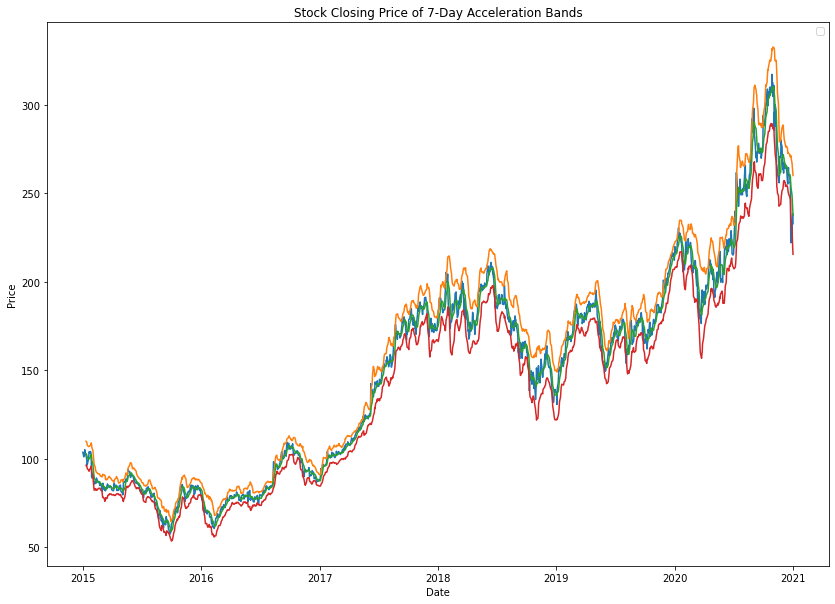

In [93]:
plt.figure(figsize=(14,10))
plt.plot(df['Adj Close'])
plt.plot(df['Upper_Band'])
plt.plot(df['Middle_Band'])
plt.plot(df['Lower_Band'])
plt.ylabel('Price')
plt.xlabel('Date')
plt.title('Stock Closing Price of ' + str(n) + '-Day Acceleration Bands')
plt.legend(loc='best')

In [94]:
from matplotlib import dates as mdates
import datetime as dt

dfc = df.copy()
dfc['VolumePositive'] = dfc['Open'] < dfc['Adj Close']
#dfc = dfc.dropna()
dfc = dfc.reset_index()
dfc['Date'] = pd.to_datetime(dfc['Date'])
dfc['Date'] = dfc['Date'].apply(mdates.date2num)
dfc.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Upper_Band,Middle_Band,Lower_Band,VolumePositive
0,16437.0,104.239998,104.720001,102.519997,103.599998,103.599998,12303400,NaN,NaN,NaN,False
1,16440.0,102.760002,103.019997,99.900002,101.000000,101.000000,18337000,NaN,NaN,NaN,False
2,16441.0,101.250000,103.849998,100.110001,103.320000,103.320000,15720400,NaN,NaN,NaN,True
3,16442.0,104.589996,104.739998,102.029999,102.129997,102.129997,11052200,NaN,NaN,NaN,False
4,16443.0,102.949997,105.339996,102.680000,105.029999,105.029999,12942100,NaN,NaN,NaN,True


Text(0.5, 0, 'Date')

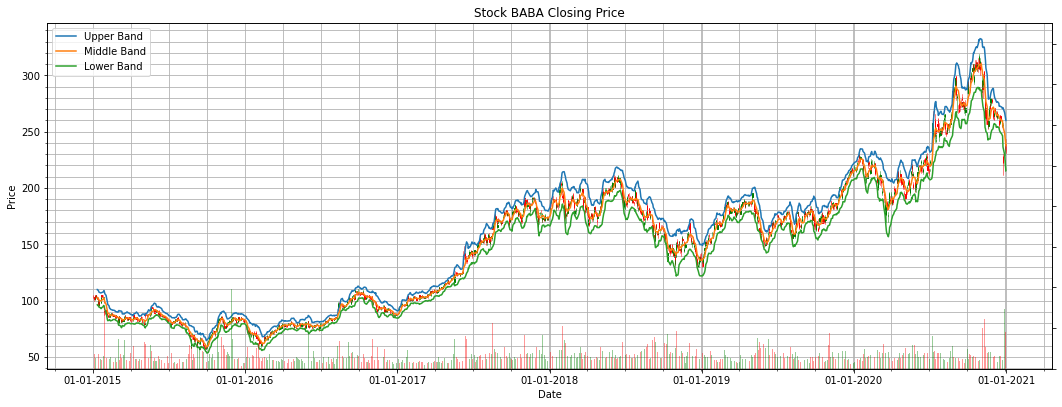

In [95]:
from mpl_finance import candlestick_ohlc

fig = plt.figure(figsize=(18,14))
ax1 = plt.subplot(2, 1, 1)
candlestick_ohlc(ax1,dfc.values, width=0.5, colorup='g', colordown='r', alpha=1.0)
ax1.plot(df['Upper_Band'], label='Upper Band')
ax1.plot(df['Middle_Band'], label='Middle Band')
ax1.plot(df['Lower_Band'], label='Lower Band')
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
ax1.grid(True, which='both')
ax1.minorticks_on()
ax1v = ax1.twinx()
colors = dfc.VolumePositive.map({True: 'g', False: 'r'})
ax1v.bar(dfc.Date, dfc['Volume'], color=colors, alpha=0.4)
ax1v.axes.yaxis.set_ticklabels([])
ax1v.set_ylim(0, 3*df.Volume.max())
ax1.set_title('Stock '+ symbol +' Closing Price')
ax1.legend(loc='best')
ax1.set_ylabel('Price')
ax1.set_xlabel('Date')

# Week #4 Trade Exeucutions:

Week #4: Starting funds as of 11/26: $245296.57

Given these results, money in each stock was allocated as such:

![Trade History](week4images\positions.PNG)

Total Funds Allocated: $64,838.12

In [97]:
#Week 4 Funds
week4start = 245296.57
week4end = 248124.59


#Week 4 starting funds
print("Week #4 starting funds as of 12/03: ${}".format(week4start))

#Week 4 ending funds
print("Week #4 ending funds as of 12/03: ${}".format(week4end))

# Percent gain/loss
percentDiffrence = ((week4start - week4end)/((week4start + week4end)/2))*-100
print("Week #4 percent gain/loss was: {}%".format(percentDiffrence))

#Profit
gain_loss = week4end - week4start
print("Week #4 profit/loss as of 12/07: +${}".format(gain_loss))

Week #4 starting funds as of 12/03: $245296.57
Week #4 ending funds as of 12/03: $248124.59
Week #4 percent gain/loss was: 1.146290523900511%
Week #4 profit/loss as of 12/07: +$2828.0199999999895


Performance History:

![Trade History](week4images\performance.PNG)